# Water Gradual Penalty

The oracle computes a **continuous distance** for water frequency:

```
plant_min = min(ideal_days, tolerated_days)
plant_max = max(ideal_days, tolerated_days)

if plant_min <= user_freq <= plant_max:
    distance = 0       # in range
elif user_freq < plant_min:
    distance = plant_min - user_freq   # below (overwatering)
else:
    distance = user_freq - plant_max   # above (underwatering)

water_match = 1 / (1 + distance)
```

Water categories: dry=7 days, moist=2 days, wet=1 day. Users have decimal `water_freq` values sampled around these anchors.

**Hypothesis:** Survival and model score should be highest when the user's watering frequency is in the plant's range, and drop as distance increases. We bucket into: **below** (overwatering), **in_range**, **above** (underwatering), then further by distance bins.

## 1. Setup & Load Data

In [10]:
import json
import sys
from collections import defaultdict
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "resources").exists():
    for c in [ROOT.parent, ROOT.parent.parent, ROOT.parent.parent.parent]:
        if (c / "resources").exists():
            ROOT = c
            break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

INTERACTIONS_PATH = ROOT / "resources" / "data" / "synthetic_interactions.json"
USERS_PATH = ROOT / "resources" / "data" / "synthetic_users.json"
PLANTS_PATH = ROOT / "resources" / "data_creating" / "permapeople_plants_mapped_normalized.json"
PLANTS_ALT = ROOT / "resources" / "data_creating" / "permapeople_plants_mapped_uniform.json"
OUTPUT_DIR = ROOT / "resources" / "verify" / "water gradual"

## 2. Helper Functions

In [11]:
from resources.ETL.feature_engineer import water_freq_to_days


def _plant_ec(plant: dict, key: str, alt: str | None = None) -> dict:
    ec = plant.get("environment_care") or {}
    return ec.get(key) or ec.get(alt or key) or {}


def compute_water_distance(user: dict, plant: dict) -> tuple[str, float] | None:
    """
    Return (bucket, distance) or None if data missing.
    bucket: 'below' | 'in_range' | 'above'
    distance: 0 if in range, positive otherwise
    """
    wr = _plant_ec(plant, "water", "water_req")
    ideal_days = wr.get("ideal_water_days") or water_freq_to_days(wr.get("ideal_water"))
    tolerated_days = wr.get("tolerated_water_days") or water_freq_to_days(wr.get("tolerated_water"))
    plant_min = min(ideal_days, tolerated_days)
    plant_max = max(ideal_days, tolerated_days)

    user_freq = user.get("water_freq")
    if user_freq is None:
        return None

    uf = float(user_freq)
    if plant_min <= uf <= plant_max:
        return ("in_range", 0.0)
    elif uf < plant_min:
        return ("below", plant_min - uf)
    else:
        return ("above", uf - plant_max)

In [12]:
def load_data():
    with open(INTERACTIONS_PATH) as f:
        interactions = json.load(f)
    with open(USERS_PATH) as f:
        users = json.load(f)
    path = PLANTS_PATH if PLANTS_PATH.exists() else PLANTS_ALT
    with open(path) as f:
        plants = json.load(f).get("plants", [])
    user_by_id = {u["user_id"]: u for u in users}
    plant_by_id = {p.get("id"): p for p in plants if p.get("id") is not None}
    return interactions, user_by_id, plant_by_id

interactions, user_by_id, plant_by_id = load_data()
print(f"{len(interactions)} interactions, {len(user_by_id)} users, {len(plant_by_id)} plants")

11206 interactions, 810 users, 1000 plants


## 3. Compute Survival by Water Bucket

Three buckets: **below** (user waters more frequently than plant needs — overwatering), **in_range** (within plant tolerance), **above** (user waters less frequently — underwatering).

In [13]:
def survival_by_water_bucket(interactions, user_by_id, plant_by_id):
    by_bucket = defaultdict(list)
    for r in interactions:
        u = user_by_id.get(r["user_id"], {})
        p = plant_by_id.get(r["plant_id"]) or {}
        if not p:
            continue
        result = compute_water_distance(u, p)
        if result is None:
            continue
        bucket, _ = result
        by_bucket[bucket].append(r.get("label", 0))

    stats = {}
    for b, labels in by_bucket.items():
        n = len(labels)
        mean = sum(labels) / n
        stats[b] = {"n": n, "survival_rate": mean}
    return stats

bucket_stats = survival_by_water_bucket(interactions, user_by_id, plant_by_id)
for b in ["below", "in_range", "above"]:
    s = bucket_stats.get(b, {})
    print(f"{b:10s}: survival={s.get('survival_rate', 0):.3f}  n={s.get('n', 0)}")

below     : survival=0.653  n=3307
in_range  : survival=0.754  n=2613
above     : survival=0.612  n=5286


## 4. (Removed — distance bin analysis not meaningful for water)

In [14]:
# Section removed: distance bin analysis is not meaningful for water.
# The three-bucket view (below / in_range / above) captures the key pattern cleanly.

## 5. Plot: Survival by Water Bucket

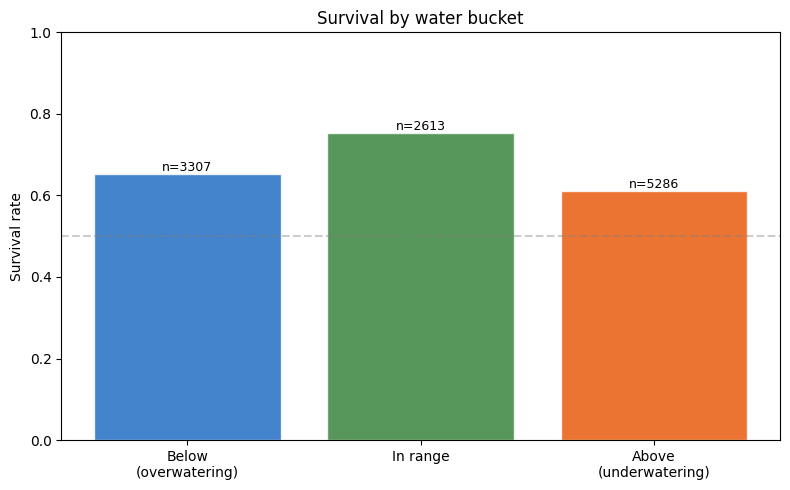

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")

bucket_order = ["below", "in_range", "above"]
bucket_labels = ["Below\n(overwatering)", "In range", "Above\n(underwatering)"]
bucket_survivals = [bucket_stats.get(b, {}).get("survival_rate", 0) for b in bucket_order]
bucket_counts = [bucket_stats.get(b, {}).get("n", 0) for b in bucket_order]
colors = ["#1565c0", "#2e7d32", "#e65100"]

bars = ax.bar(bucket_labels, bucket_survivals, color=colors, alpha=0.8, edgecolor="white")
for bar, n in zip(bars, bucket_counts):
    ax.annotate(f"n={n}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Survival rate")
ax.set_title("Survival by water bucket")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.4)

plt.tight_layout()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "water_gradual_survival.png", dpi=120, bbox_inches="tight", facecolor="white")
plt.show()

## 6. Model: Does It Learn the Water Gradient?

Load the two-tower model and compute mean model score per bucket and per distance bin.

In [16]:
import torch
from resources.ETL.feature_engineer import apply_user_embeddings, apply_categorical_embeddings

users_list = list(user_by_id.values())
plants_list = list(plant_by_id.values())
apply_user_embeddings(users_list)
apply_categorical_embeddings(plants_list)
user_by_id = {u["user_id"]: u for u in users_list}
plant_by_id = {p.get("id"): p for p in plants_list}

model = None
for p in [ROOT / "resources" / "two_tower_training" / "two_tower.pt",
          ROOT / "resources" / "two_tower_training" / "output" / "two_tower.pt"]:
    if p.exists():
        ckpt = torch.load(p, map_location="cpu", weights_only=True)
        state = ckpt.get("model_state", ckpt)
        if any("user_tower.mlp" in k for k in state.keys()):
            from resources.two_tower_training.two_tower_model import TwoTowerModel
            model = TwoTowerModel()
            model.load_state_dict(state, strict=True)
            model.eval()
            print(f"Loaded model from {p}")
            break
if model is None:
    print("Model not found — skip model analysis.")

Loaded model from /Users/yemarnaung/Documents/Projects/HowToKeepYourPlantsAlive/resources/two_tower_training/output/two_tower.pt


In [17]:
def model_scores_by_water(interactions, user_by_id, plant_by_id, model):
    """Compute mean model score per water bucket."""
    batch_u, batch_p, batch_bucket = [], [], []
    for r in interactions:
        u = user_by_id.get(r["user_id"], {})
        p = plant_by_id.get(r["plant_id"]) or {}
        if not p or "categorical_embedding" not in p:
            continue
        u_emb = u.get("categorical_embedding")
        if not u_emb or len(u_emb) != 21:
            continue
        result = compute_water_distance(u, p)
        if result is None:
            continue
        bucket, _ = result
        batch_u.append(list(u_emb) + [0.0] * 64 + [0.0] * 64)
        batch_p.append(p["categorical_embedding"])
        batch_bucket.append(bucket)

    if not batch_u:
        return None
    u_t = torch.tensor(batch_u, dtype=torch.float32)
    p_t = torch.tensor(batch_p, dtype=torch.float32)
    with torch.no_grad():
        scores = model(u_t, p_t).numpy()

    by_bucket = defaultdict(list)
    for bk, sc in zip(batch_bucket, scores):
        by_bucket[bk].append(float(sc))

    return {b: {"n": len(v), "mean_score": sum(v) / len(v)} for b, v in by_bucket.items()}

if model:
    model_bucket_stats = model_scores_by_water(interactions, user_by_id, plant_by_id, model)
    if model_bucket_stats:
        for b in ["below", "in_range", "above"]:
            s = model_bucket_stats.get(b, {})
            print(f"{b:10s}: model_score={s.get('mean_score', 0):.4f}  n={s.get('n', 0)}")
else:
    model_bucket_stats = None
    print("Model not loaded — skip.")

below     : model_score=3.8561  n=3307
in_range  : model_score=4.1377  n=2613
above     : model_score=3.7691  n=5286


## 7. Plot: Survival + Model Score (Dual Y-Axis)

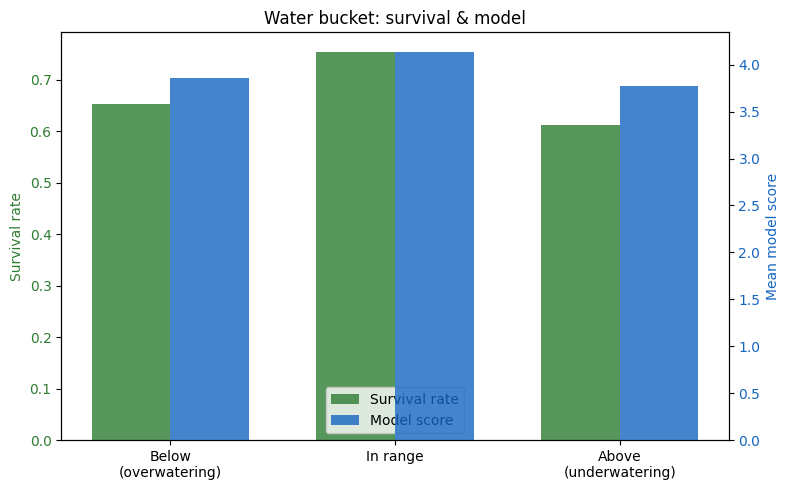

In [18]:
if model_bucket_stats:
    import numpy as np

    fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")

    bucket_order = ["below", "in_range", "above"]
    bucket_labels = ["Below\n(overwatering)", "In range", "Above\n(underwatering)"]
    x_bk = np.arange(len(bucket_order))
    width = 0.35

    surv_vals = [bucket_stats.get(b, {}).get("survival_rate", 0) for b in bucket_order]
    model_vals = [model_bucket_stats.get(b, {}).get("mean_score", 0) for b in bucket_order]

    ax_twin = ax.twinx()
    bars_s = ax.bar(x_bk - width / 2, surv_vals, width, label="Survival rate", color="#2e7d32", alpha=0.8)
    bars_m = ax_twin.bar(x_bk + width / 2, model_vals, width, label="Model score", color="#1565c0", alpha=0.8)
    ax.set_xticks(x_bk)
    ax.set_xticklabels(bucket_labels)
    ax.set_ylabel("Survival rate", color="#2e7d32")
    ax_twin.set_ylabel("Mean model score", color="#1565c0")
    ax.tick_params(axis="y", labelcolor="#2e7d32")
    ax_twin.tick_params(axis="y", labelcolor="#1565c0")
    ax.set_title("Water bucket: survival & model")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax_twin.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="lower center")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "water_gradual_model.png", dpi=120, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print("Model not loaded — combined plot skipped.")

## 8. Summary

- **Oracle:** `water_match = 1 / (1 + distance)` where distance = how far the user's watering frequency is from the plant's acceptable `[plant_min, plant_max]` range.
- **Buckets:** We categorize interactions into three buckets: `below` (overwatering), `in_range`, and `above` (underwatering). This captures the key pattern cleanly.
- **Survival:** Highest for `in_range`, lower for `below`/`above`.
- **Model:** If the model learned the water penalty, model scores should follow the same pattern — highest in range, lower for mismatches.
- **Asymmetry:** The oracle treats overwatering and underwatering symmetrically, but the model might not.

Note: Distance bin analysis (finer granularity like 0, (0,1], (1,2], etc.) was removed because water frequency is continuous rather than ordinal, making arbitrary bins less meaningful. The three-bucket view tells a clearer, more intuitive story.